/home/miquel/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


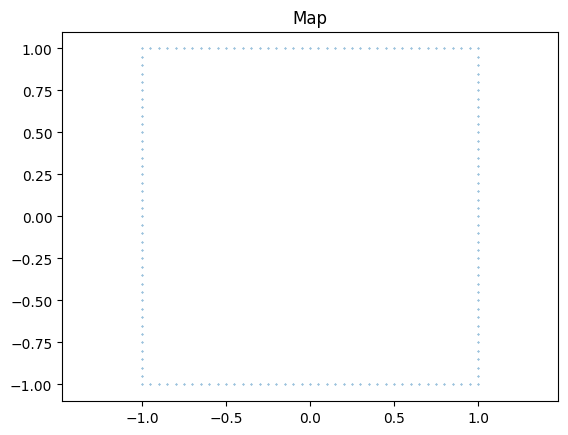

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Create a fake map (2x2 meter empty square, with 1mm resolution)
simulation_map = []
# North wall
simulation_map.extend([[x, -1] for x in np.arange(-1, 1, 0.05)])
# East wall
simulation_map.extend([[1, y] for y in np.arange(-1, 1, 0.05)])
# South wall
simulation_map.extend([[x, 1] for x in np.arange(1, -1, -0.05)])
# West wall
simulation_map.extend([[-1, y] for y in np.arange(1, -1, -0.05)])
simulation_map = np.array(simulation_map)

# Plot the map
plt.figure()
plt.scatter(simulation_map[:, 0], simulation_map[:, 1], s=0.1)
plt.axis('equal')
plt.title('Map')
plt.show()

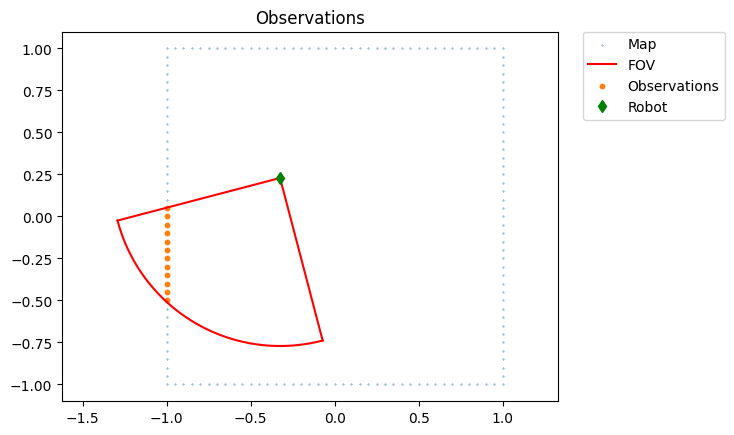

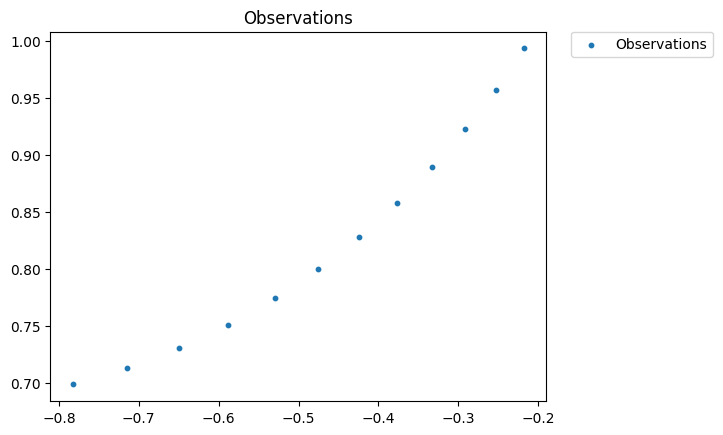

In [2]:
# Create a function that, given a position and a map, returns the range and bearing of
# the edges of the map, assuming a FOV of 90 degrees, a maximum range of 1 meter and
# a total of 90 measurements.
def get_observations(robot_pose, simulation_map, fov, max_range):
    """Get the observations from the robot pose and the map.

    Parameters
    ----------
    robot_pose : numpy array
        The robot pose as (x, y, gamma).
    map : numpy array
        The map as an array of (x, y) points.

    Returns
    -------
    numpy array
        The observations as an array of (range, bearing) points.
    """
    # Get the robot pose
    robot_x = robot_pose[0]
    robot_y = robot_pose[1]
    robot_gamma = robot_pose[2]
    # Get the map points
    map_x = simulation_map[:, 0]
    map_y = simulation_map[:, 1]
    # Calculate the range and bearing
    range_obs = np.linalg.norm(simulation_map - robot_pose[0:2], axis=1)
    bearing = np.arctan2(map_y - robot_y, map_x - robot_x) - robot_gamma
    # Bearing should be +/- np.pi
    bearing = (bearing + np.pi) % (2 * np.pi) - np.pi
    observations = np.array([range_obs, bearing])
    # Filter the observations
    observations = observations[:, (observations[0] < max_range) & (observations[1] < fov / 2) & (observations[1] > -fov / 2)]
    # Return the observations
    return observations.T

# Test the function
robot_pose = np.array([-0.3248179, 0.22909425, 4.18318531]) #np.array([0.5, 0.2, 1.2])
fov = np.pi / 2
range_max = 1.0

# Generate observations
observations = get_observations(robot_pose, simulation_map, fov, range_max)

# Plot the FOV
fov_points = np.array(
    [
        [range_max * np.cos(fov / 2 + robot_pose[2]), range_max * np.sin(fov / 2 + robot_pose[2])],
        [0, 0],
        [range_max * np.cos(-fov / 2 + robot_pose[2]), range_max * np.sin(-fov / 2 + robot_pose[2])],
    ]
)
fov_points = fov_points + robot_pose[0:2]
# Add a semicircle
t = np.linspace(- fov / 2+ robot_pose[2], fov / 2+ robot_pose[2], 100)
x = range_max * np.cos(t) + robot_pose[0]
y = range_max * np.sin(t) + robot_pose[1]

# Plot the observations
plt.figure()
plt.scatter(simulation_map[:, 0], simulation_map[:, 1], s=0.1, label='Map')
plt.plot(x, y, c="r")
plt.plot(fov_points[:, 0], fov_points[:, 1], c="r", label="FOV")
plt.scatter(robot_pose[0] + observations[:, 0] * np.cos(observations[:, 1] + robot_pose[2]),
            robot_pose[1] + observations[:, 0] * np.sin(observations[:, 1] + robot_pose[2]), s=10, label='Observations')
plt.plot(robot_pose[0], robot_pose[1], 'gd', label='Robot')
plt.axis('equal')
plt.title('Observations')
# Place legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

plt.figure()
plt.scatter(observations[:, 1], observations[:, 0], s=10, label='Observations')
plt.title('Observations')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()


Step 0
Number of effective particles:  50.000000000000036


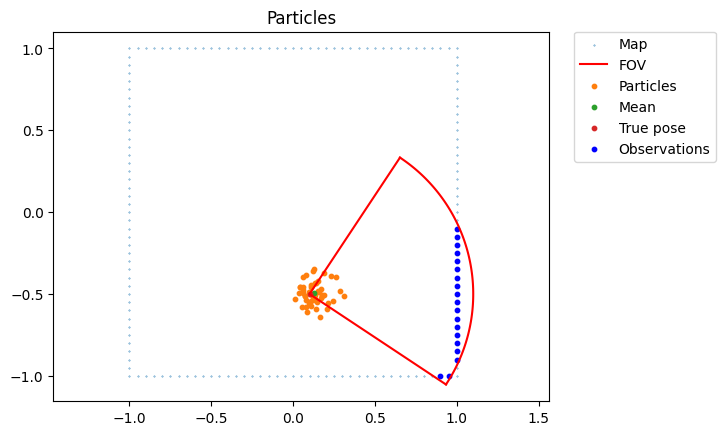

Step 1
Number of effective particles:  49.270175821376014


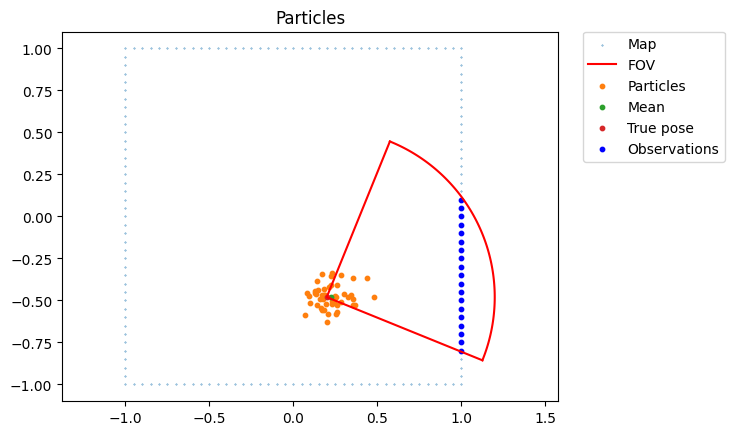

Step 2
Number of effective particles:  48.6220517561877


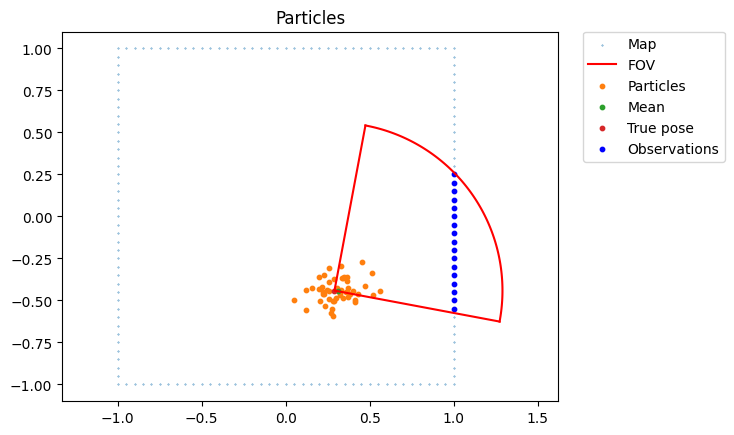

Step 3
Number of effective particles:  47.25467507630107


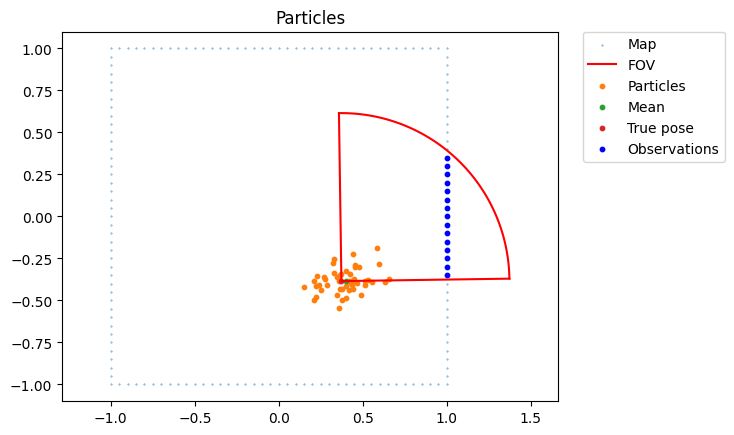

Step 4
Number of effective particles:  46.61060540691544


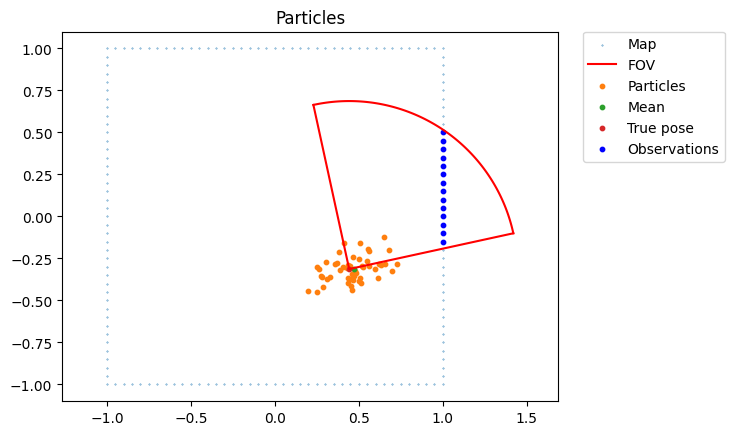

Step 5
Number of effective particles:  46.09572492708303


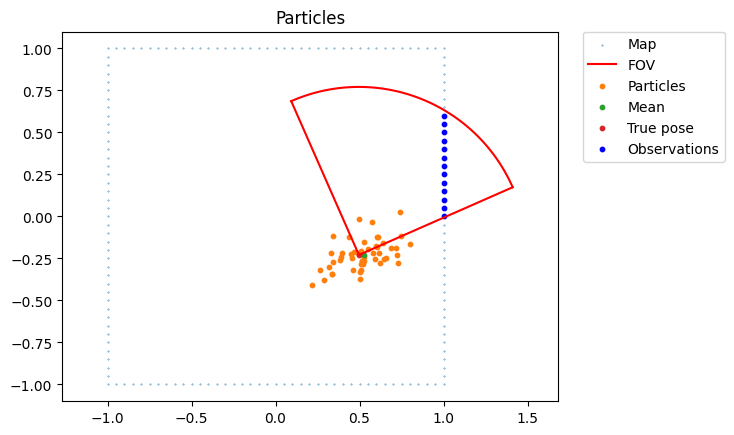

Step 6
Number of effective particles:  44.33549255217616


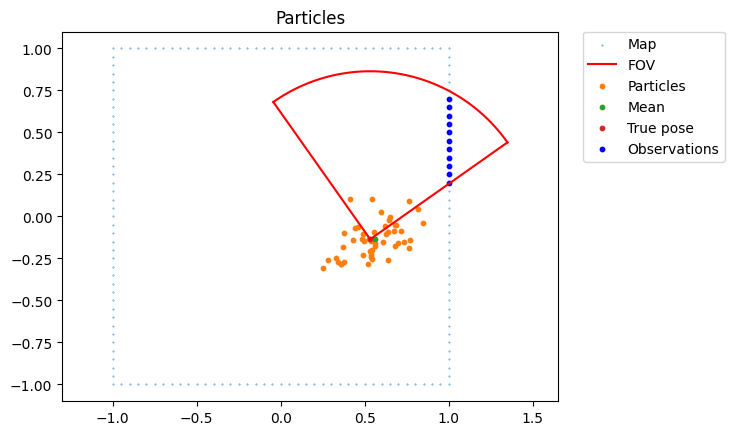

Step 7
Number of effective particles:  42.91771973080093


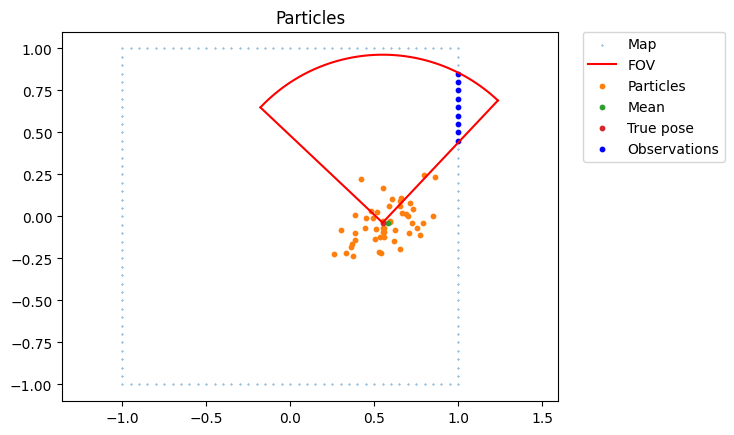

Step 8
Number of effective particles:  37.913686030581495


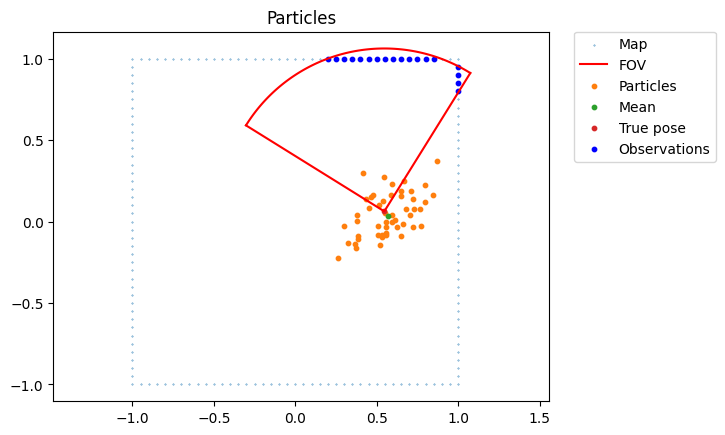

Step 9
Number of effective particles:  37.040754776567994


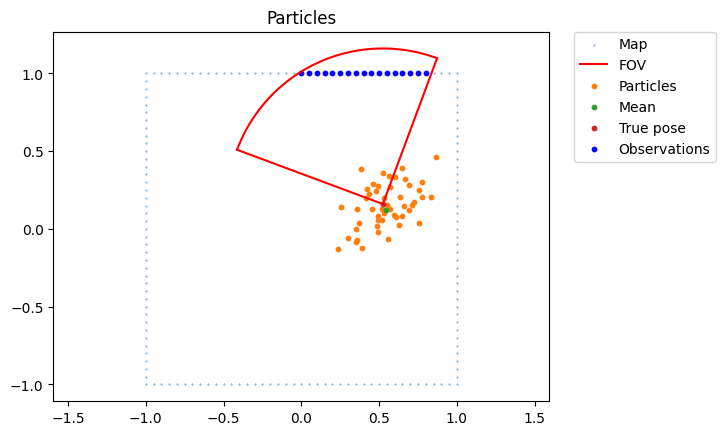

Step 10
Number of effective particles:  36.60959176026821


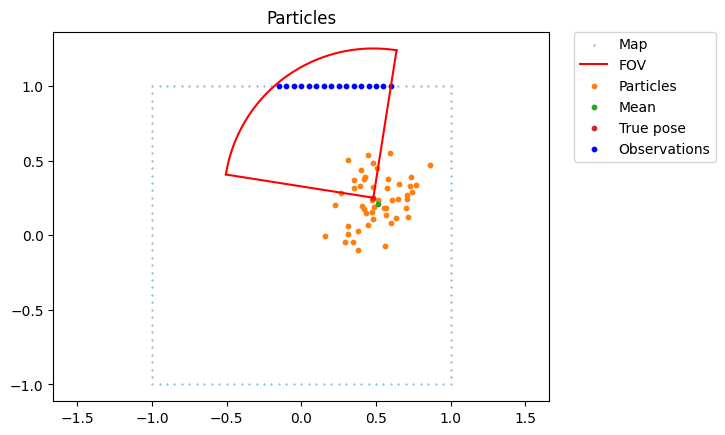

Step 11
Number of effective particles:  36.29391000781229


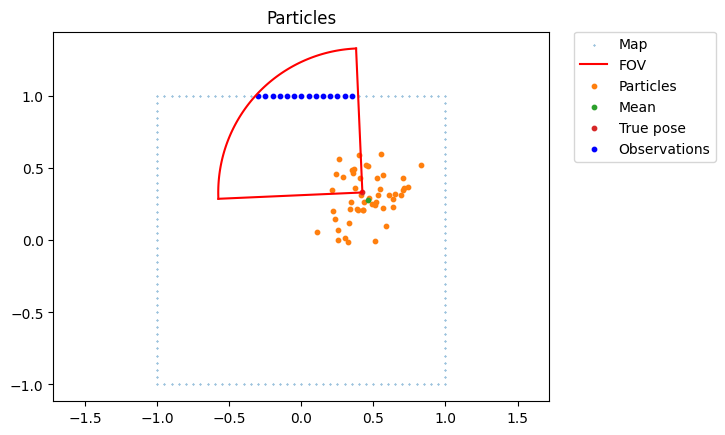

Step 12
Number of effective particles:  35.92375493504971


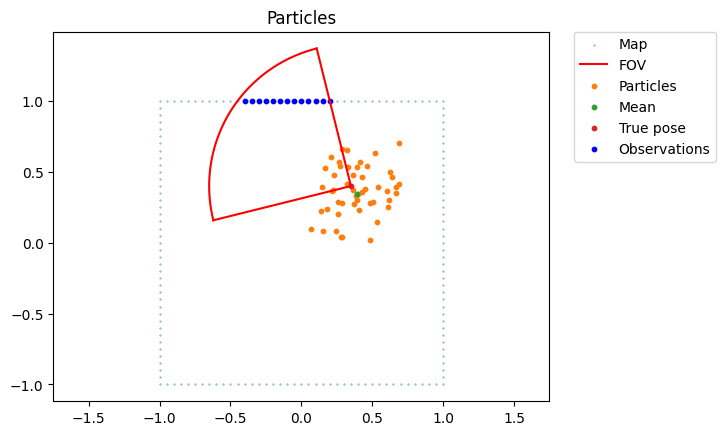

Step 13
Number of effective particles:  36.216381062278


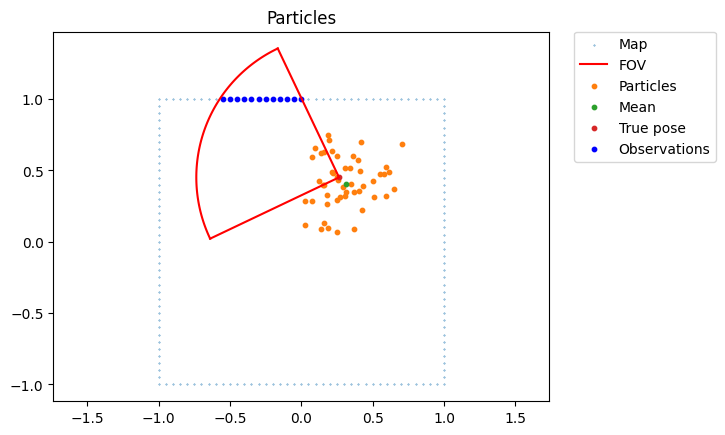

Step 14
Number of effective particles:  34.721132260575025


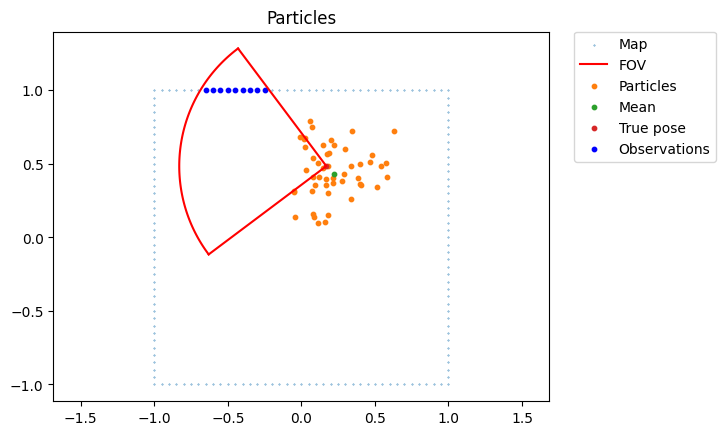

Step 15
Number of effective particles:  30.32200270293361


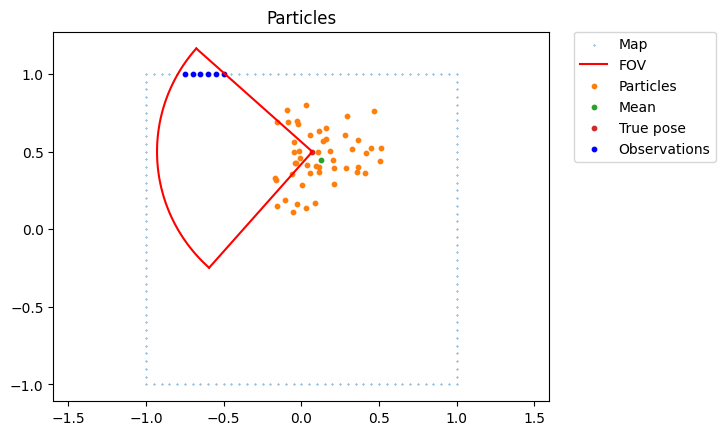

Step 16
Number of effective particles:  9.656541044306683
Resampling


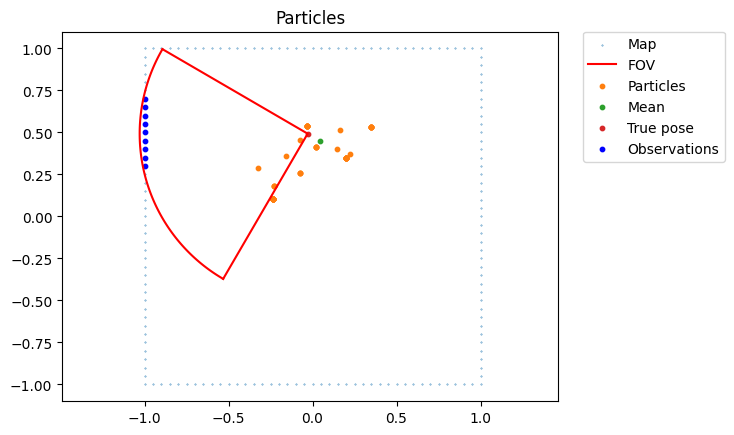

Step 17
Number of effective particles:  14.468717483890199
Resampling


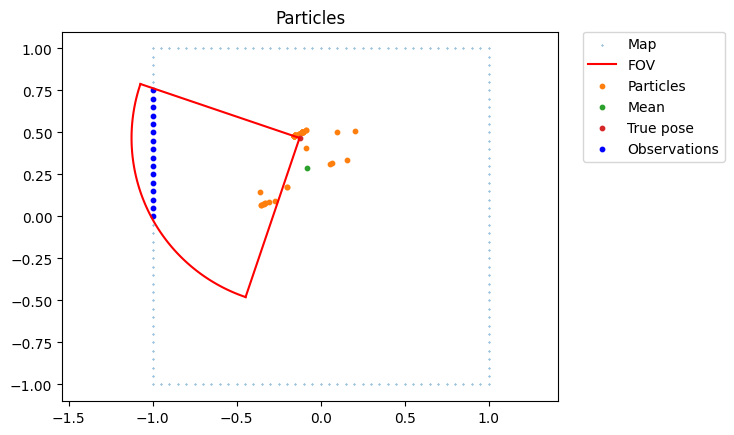

Step 18
Number of effective particles:  8.681927188844599
Resampling


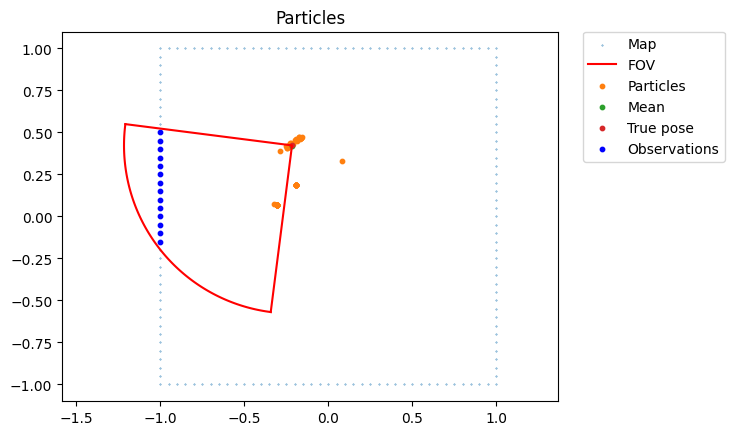

Step 19
Number of effective particles:  25.921642948331566


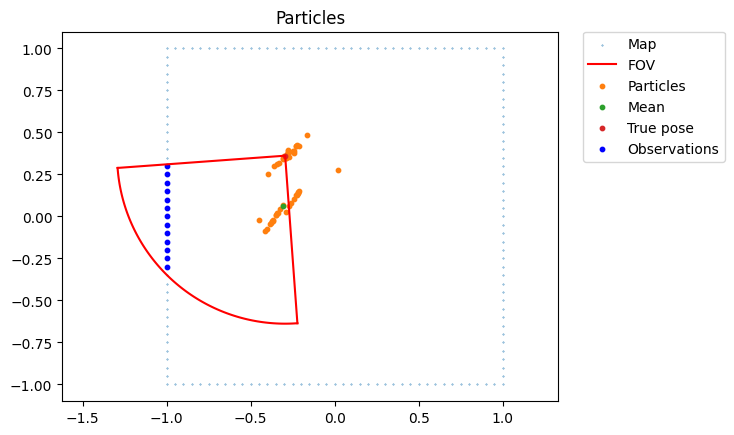

Step 20
Number of effective particles:  25.921642948331566


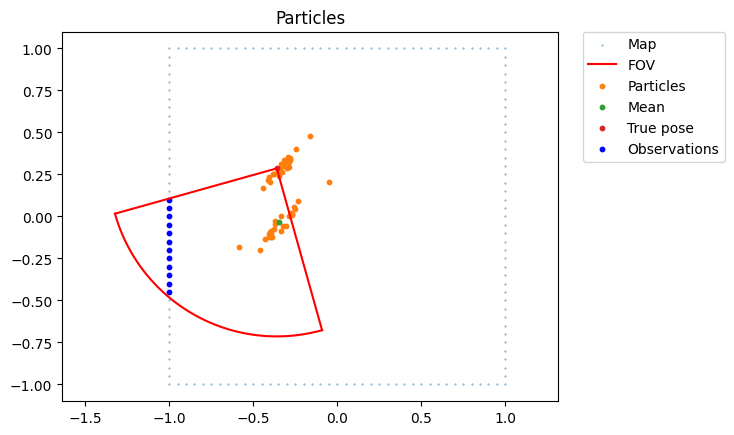

Step 21
Number of effective particles:  25.921642948331566


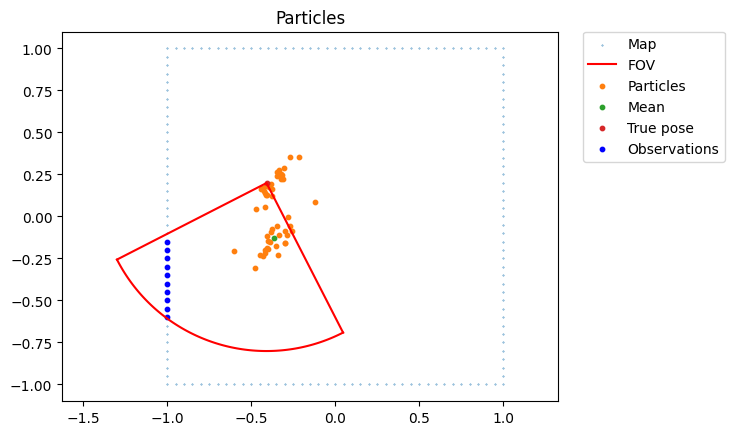

Step 22
Number of effective particles:  25.921642948331566


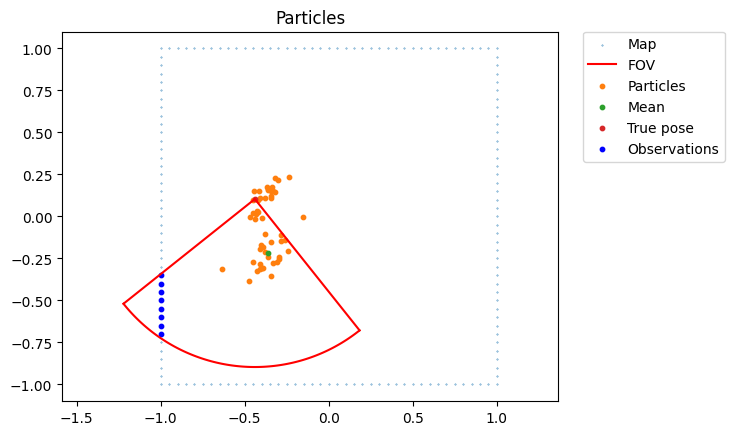

Step 23
Number of effective particles:  25.921642948331566


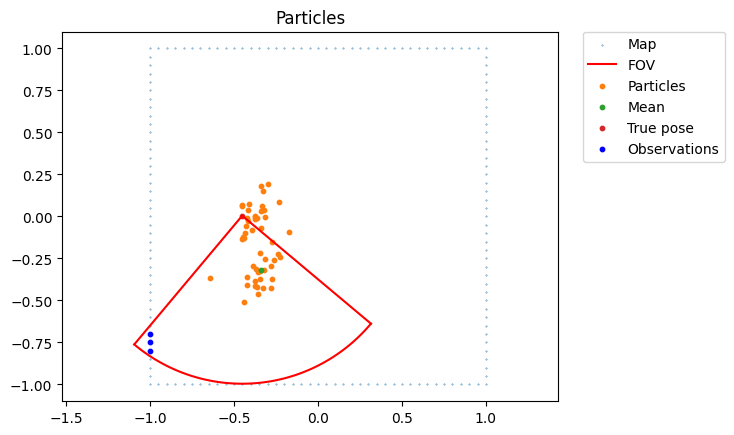

Step 24
Number of effective particles:  25.921642948331566


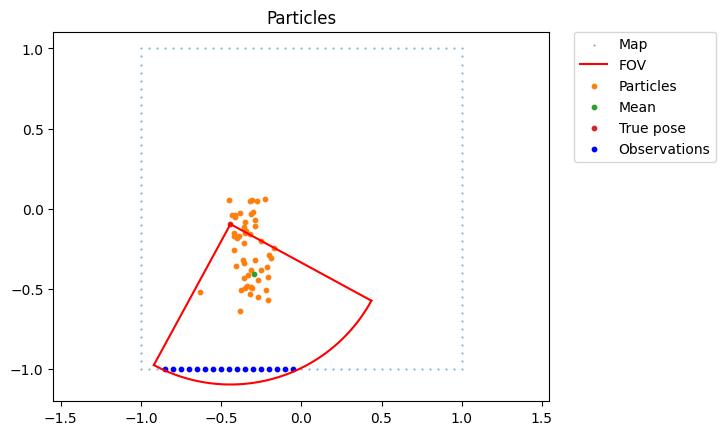

Step 25
Number of effective particles:  25.921642948331566


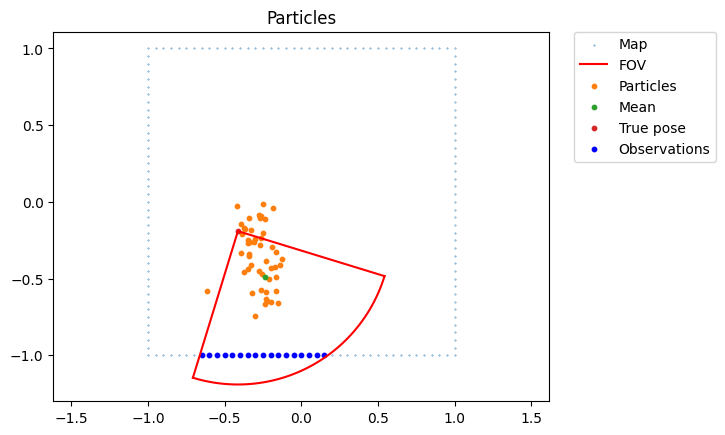

Step 26
Number of effective particles:  25.921642948331566


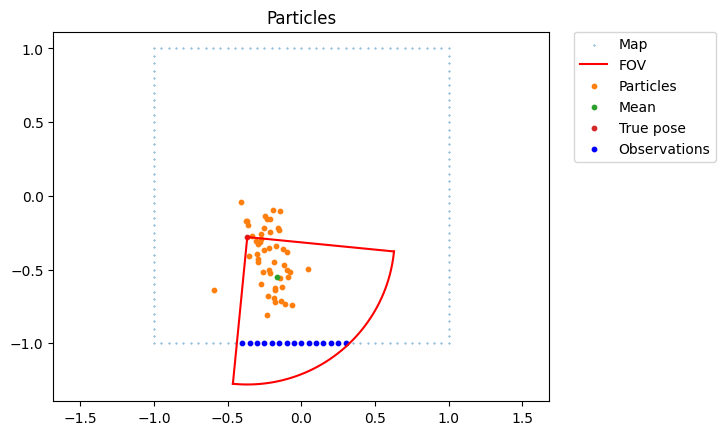

Step 27
Number of effective particles:  25.921642948331566


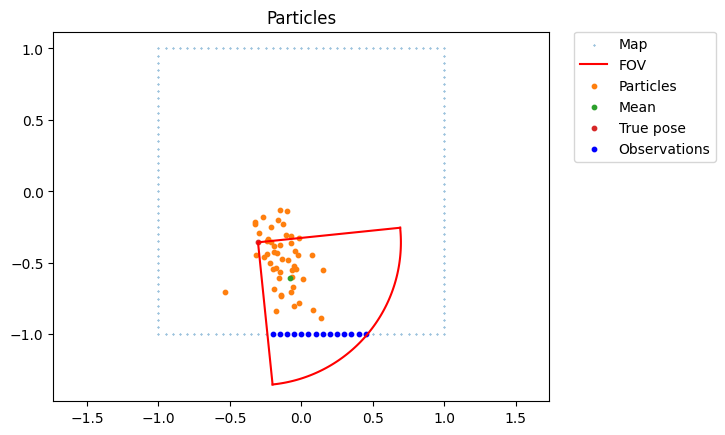

Step 28
Number of effective particles:  25.921642948331566


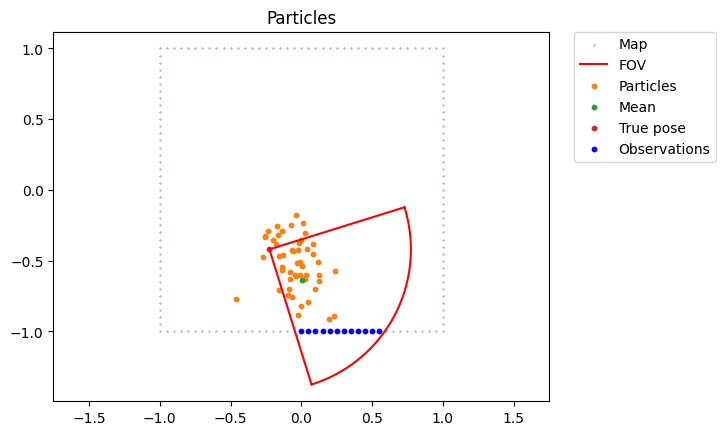

Step 29
Number of effective particles:  17.850548152358595
Resampling


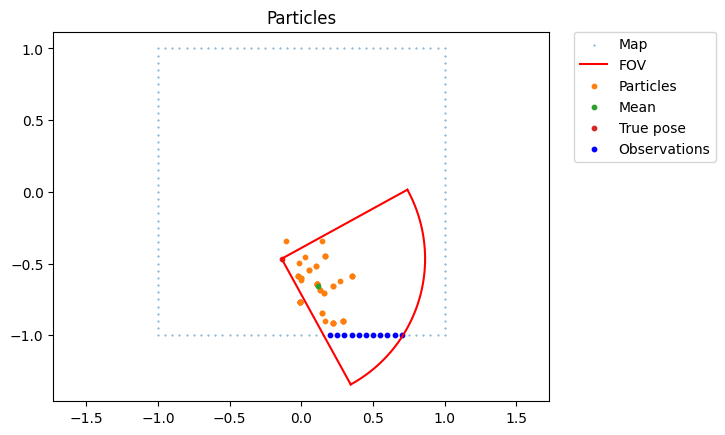

Step 30
Number of effective particles:  30.310645726009554


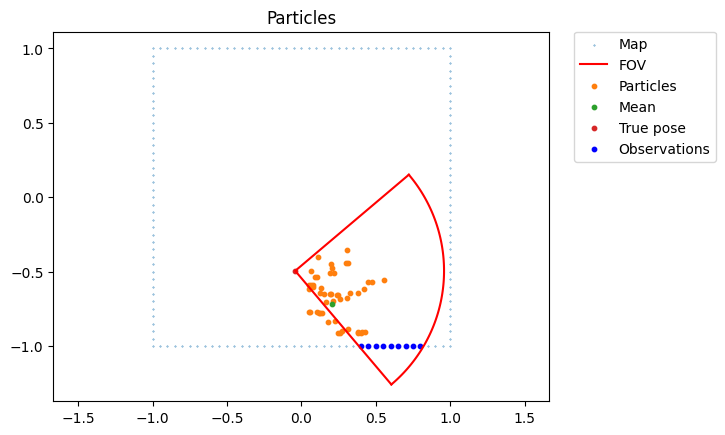

Step 31
Number of effective particles:  23.838840397020984
Resampling


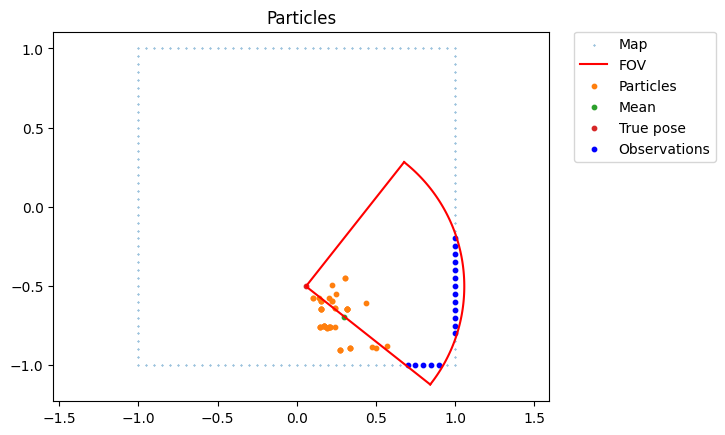

Step 32
Number of effective particles:  33.877814277383834


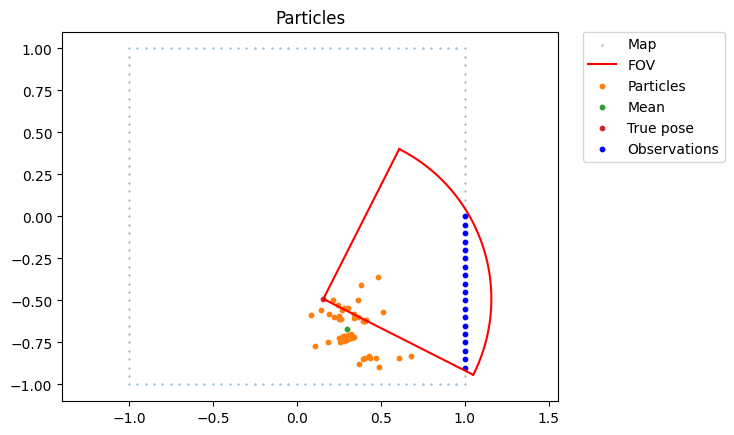

Step 33
Number of effective particles:  28.989111119232973


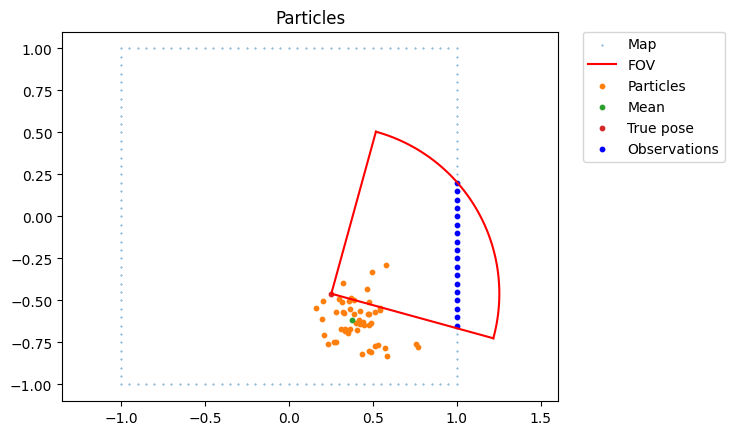

Step 34
Number of effective particles:  25.42724486926576


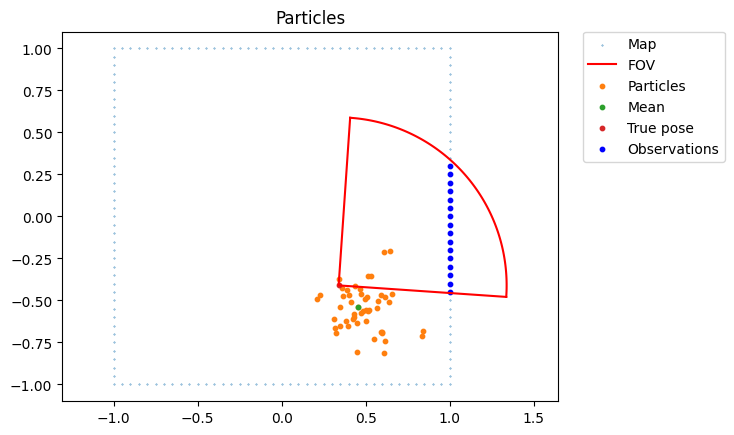

Step 35
Number of effective particles:  22.141908374768942
Resampling


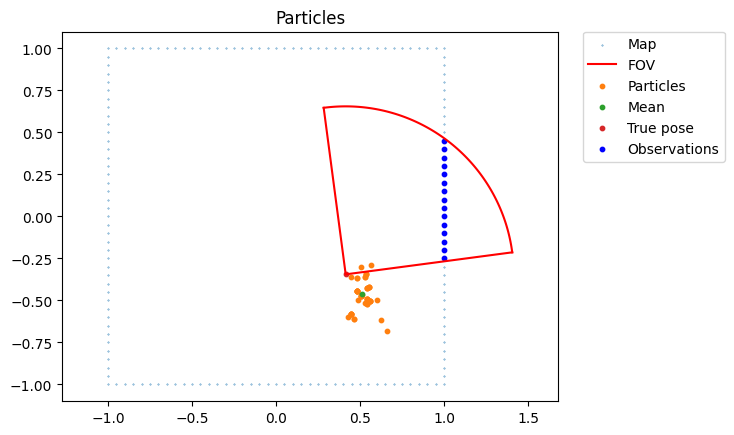

Step 36
Number of effective particles:  37.52461522899554


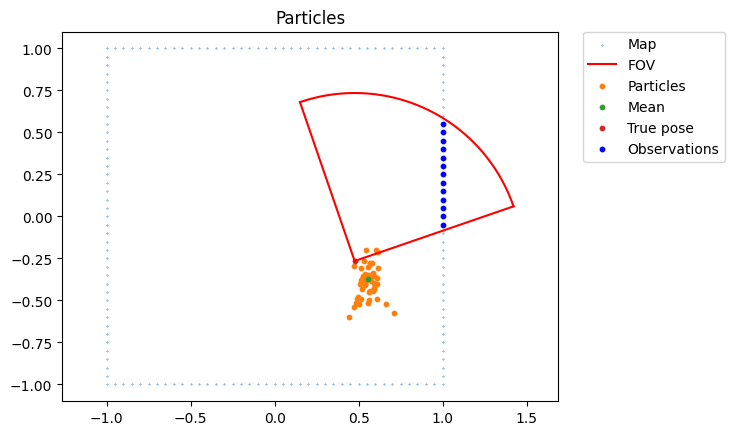

Step 37
Number of effective particles:  34.079261627152945


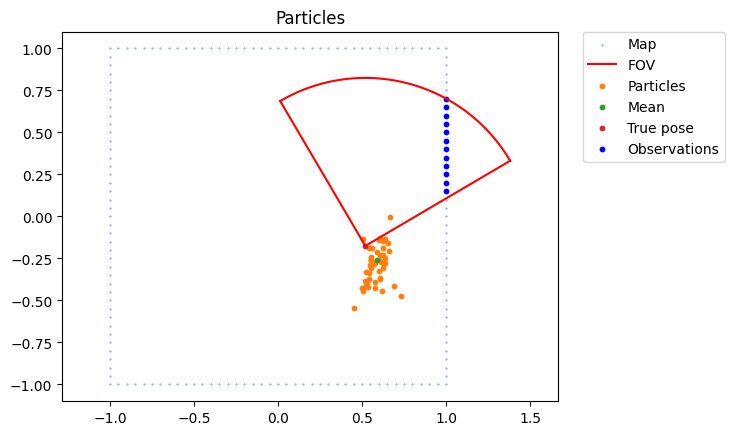

Step 38
Number of effective particles:  29.926354142895022


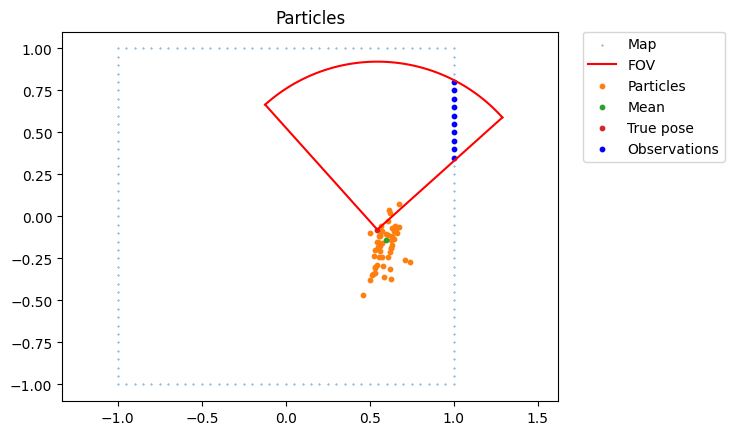

Step 39
Number of effective particles:  27.310574262864705


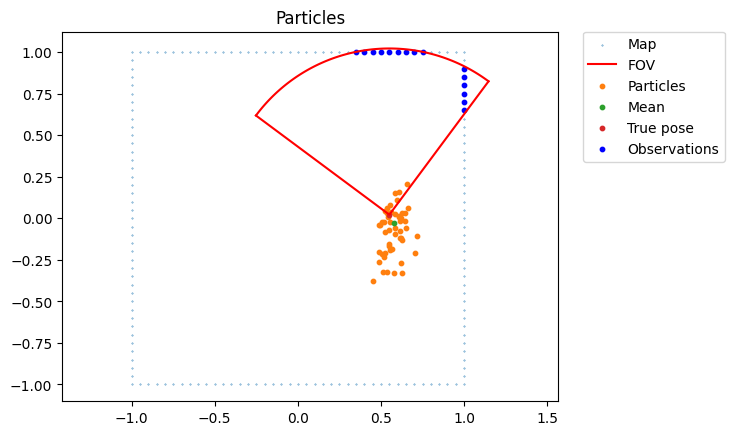

Step 40
Number of effective particles:  25.49842623619469


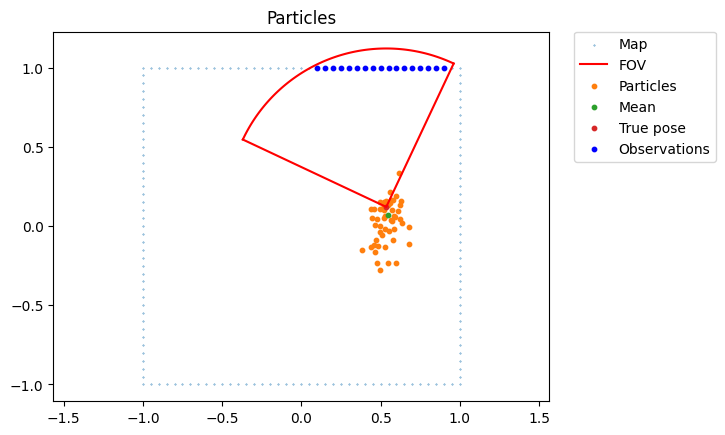

Step 41
Number of effective particles:  24.42312441353343
Resampling


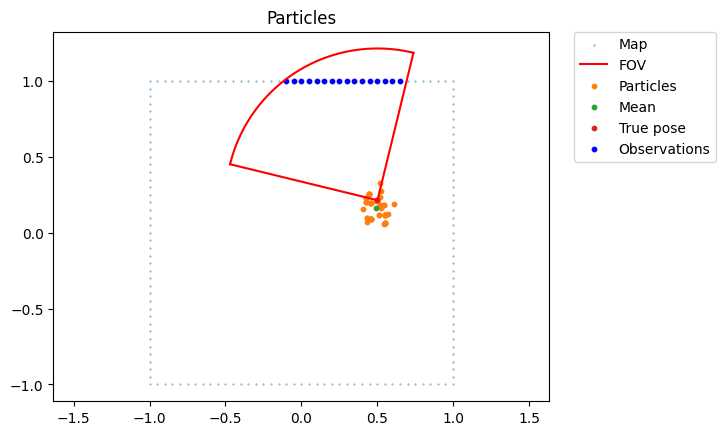

Step 42
Number of effective particles:  39.05065359059304


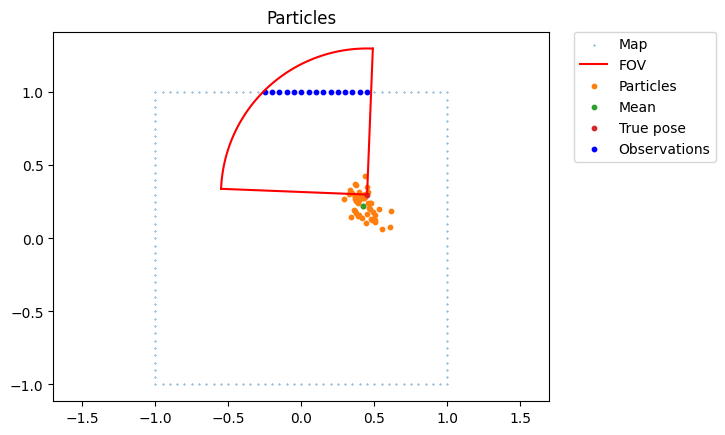

Step 43
Number of effective particles:  35.09579576197341


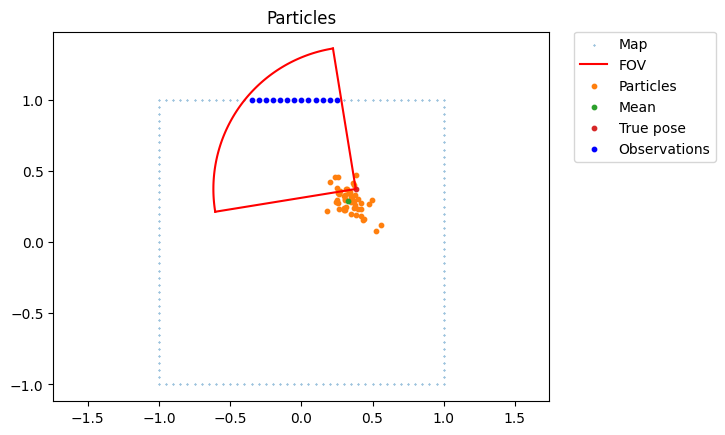

Step 44
Number of effective particles:  31.019592105185772


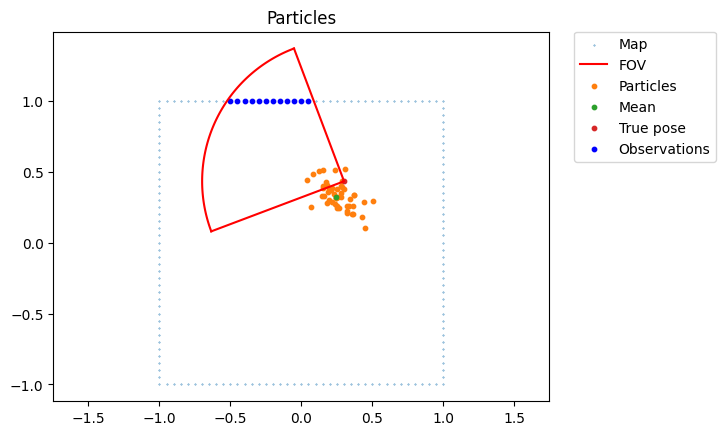

Step 45
Number of effective particles:  26.61625586037426


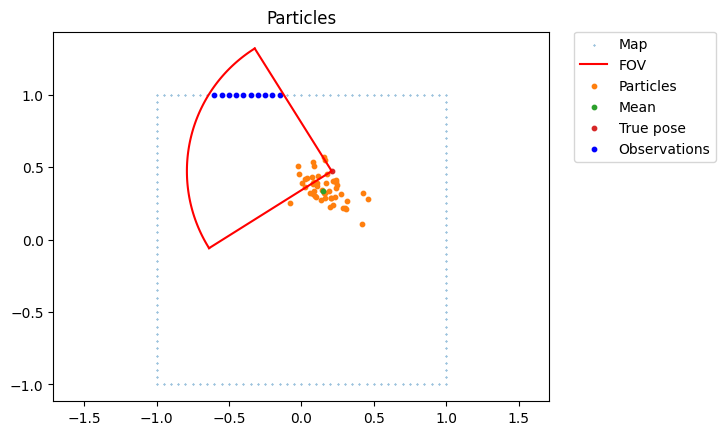

Step 46
Number of effective particles:  22.544304600640242
Resampling


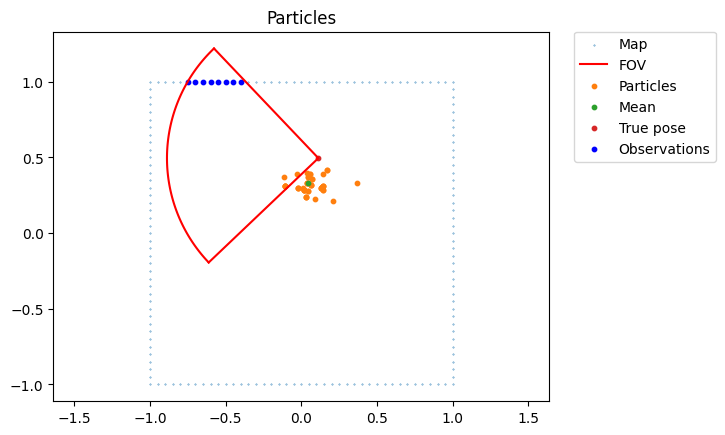

Step 47
Number of effective particles:  32.67992591637639


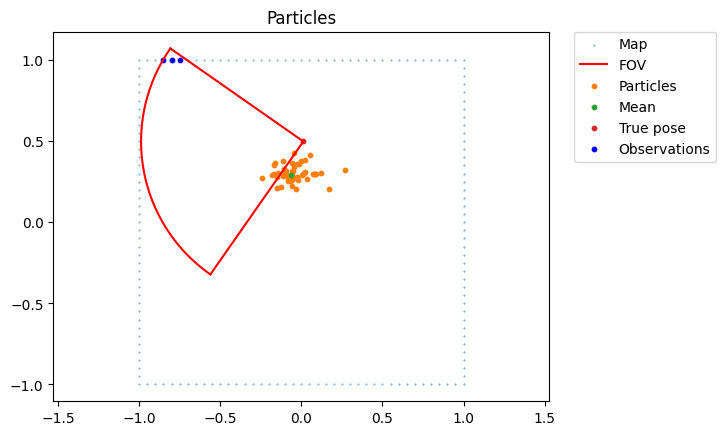

Step 48
Number of effective particles:  15.409311722752522
Resampling


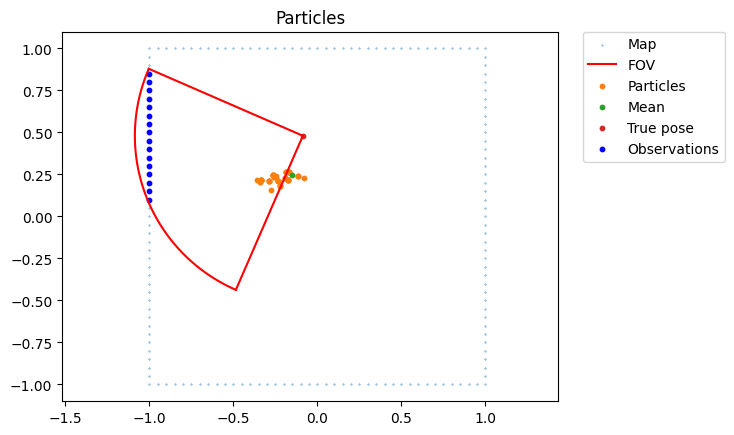

Step 49
Number of effective particles:  19.578002455244587
Resampling


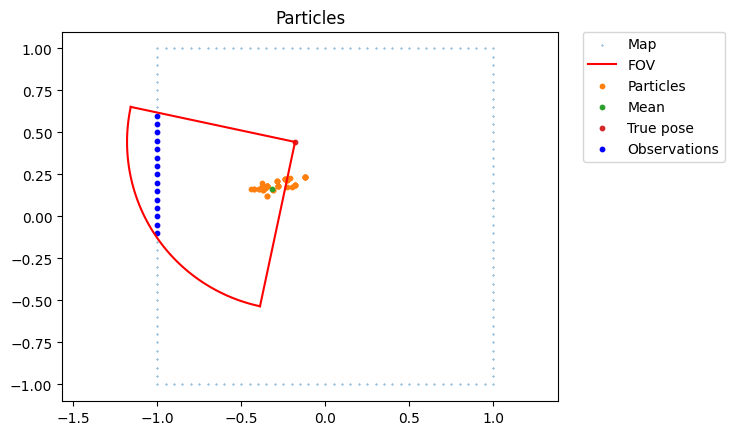

Step 50
Number of effective particles:  44.82816597512004


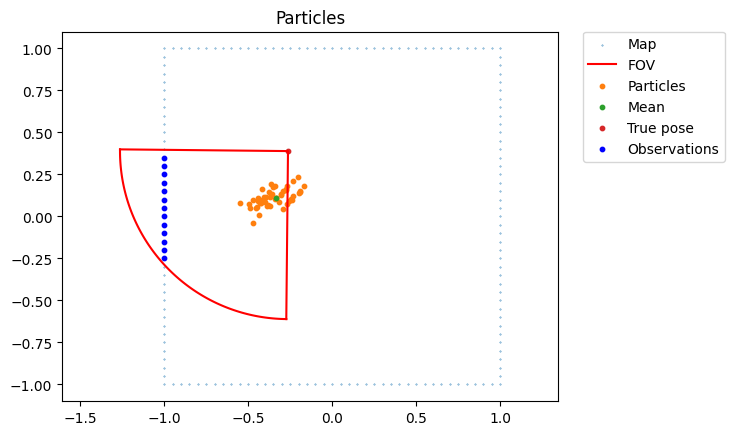

In [11]:
from pygp_particle_filter import ParticleFilter

# Create a particle filter
num_particles = 50
x_range=[-0.05, 0.05]
y_range=[-0.6, -0.4]
gamma_range=[-0.05, 0.05]
motion_noise=[0.05, 0.05, 0.005, 0.05, 0.025]

robot_pose = np.array([0.0, -0.5, 0.0])

particle_filter = ParticleFilter(num_particles, 
                                 x_range, 
                                 y_range, 
                                 gamma_range,
                                 motion_noise)

num_steps = range(51)

# v = w * r
# for a r = 0.5 m and a linear speed of 0.1, w = 0.2
linear_speed = 0.1
angular_speed = 0.2
observation_std = 0.1
length_scale = 0.1

lidar_fov = np.pi / 2
lidar_range_max = 1.0

dt = 1.0
current_time = 0.0
control_input = [0.0, 0.0, 0.0]

plt.figure()

for i in num_steps:
    print('Step {}'.format(i))
    # Timestep 
    current_time += dt
    
    # Update control input
    control_input = np.array([current_time, linear_speed, angular_speed])

    # Predict the next positions
    particle_filter.predict(control_input)
    
    # Move the GT robot too
    robot_pose[0] += control_input[1] * np.cos(robot_pose[2]) * dt
    robot_pose[1] += control_input[1] * np.sin(robot_pose[2]) * dt
    robot_pose[2] += control_input[2] * dt
    robot_pose[2] = robot_pose[2] % (2*np.pi) 
    
    mean_pose = particle_filter.mean_pose
    observations = get_observations(robot_pose, simulation_map, lidar_fov, lidar_range_max)

    ## Run update 
    particle_filter.observation_update(observations,  observation_std, length_scale)

    ## PLOTTING
    # Get the particles for plotting
    particles_x = [p.x for p in particle_filter.particles]
    particles_y = [p.y for p in particle_filter.particles]
    # Plot the FOV
    fov_points = np.array(
        [
            [lidar_range_max * np.cos(lidar_fov / 2 + robot_pose[2]), 
             lidar_range_max * np.sin(lidar_fov / 2 + robot_pose[2])],
            [0, 0],
            [lidar_range_max * np.cos(-lidar_fov / 2 + robot_pose[2]), 
             lidar_range_max * np.sin(-lidar_fov / 2 + robot_pose[2])],
        ]
    )
    fov_points = fov_points + robot_pose[0:2]
    # Add a semicircle
    t = np.linspace(- lidar_fov / 2+ robot_pose[2], lidar_fov / 2+ robot_pose[2], 100)
    x = lidar_range_max * np.cos(t) + robot_pose[0]
    y = lidar_range_max * np.sin(t) + robot_pose[1]
    # Plot the particles
    plt.clf()
    plt.scatter(simulation_map[:, 0], simulation_map[:, 1], s=0.1, label='Map')
    plt.plot(x, y, c="r")
    plt.plot(fov_points[:, 0], fov_points[:, 1], c="r", label="FOV")
    plt.scatter(particles_x, particles_y, s=10, label='Particles')
    plt.scatter(mean_pose[0], mean_pose[1], s=10, label='Mean')
    plt.scatter(robot_pose[0], robot_pose[1], s=10, label='True pose')
    plt.scatter(robot_pose[0] + observations[:, 0] * np.cos(observations[:, 1] + robot_pose[2]),
                robot_pose[1] + observations[:, 0] * np.sin(observations[:, 1] + robot_pose[2]), c="blue", s=10, label='Observations')
    plt.axis('equal')
    plt.title('Particles')
    # Place legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.show()


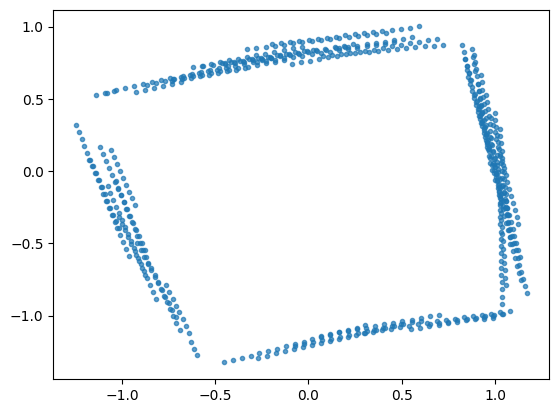

In [18]:
# Plot one particle observation map
example_particle = particle_filter.particles[0]

obs = example_particle.observations

plt.figure()
plt.plot(obs[:, 0], obs[:, 1], '.', alpha=0.7)
plt.show()